## Price Elasticity Model


### Import necessary library

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


### Load the Dataset

In [156]:
fitness_data = pd.read_excel("Cleaned_Preprocessed_Dataset_Yogeshwar Tribhuvan.xlsx")

### Dataset Information


In [157]:
fitness_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ActivitySiteID       3289 non-null   str           
 1   ActivityDescription  3289 non-null   str           
 2   BookingEndDate       3289 non-null   datetime64[us]
 3   BookingStartTime     3289 non-null   datetime64[us]
 4   MaxBookees           3289 non-null   int64         
 5   Number Booked        3289 non-null   int64         
 6   Price (INR)          3289 non-null   int64         
dtypes: datetime64[us](2), int64(3), str(2)
memory usage: 258.3 KB


In [158]:
fitness_data["ActivityDescription"].unique()

<ArrowStringArray>
[  '20-20-20  2.45pm-3.45pm',      '20-20-20 7.00-8.00pm',
     '20-20-20 9.30-10.30am',        '20:20:20  10-11 Am',
   '20:20:20  10.00-11.00am',    '20:20:20  11am -12noon',
    '20:20:20  9.30-10.30am',     '20:20:20 9.30-10.30am',
   '45min Madness 9.15-10am',     '5.30-6.30pm Body Cond',
 ...
   'Studio Cyc 9.05 -9.55am',      'B L T Antenatal Mums',
         'B L T Chair Based',     'Body Cond 5.45-6.45pm',
       'Body Cond 1745-1845',   'Purestretch 6.45-7.45pm',
  'Family Bootcamp 4-4.45pm',     'Wm Better Living Team',
 'B L T- Weight Manage Clas', 'Strokeskill 19.15-20.15pm']
Length: 280, dtype: str

In [159]:
fitness_data.describe()

,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
count,3289,3289,3289.000000,3289.000000,3289.000000
mean,2018-05-16 08:58:57.610215,1900-01-01 13:38:29.425358,32.179386,17.088781,1850.231377
min,2018-04-01 00:00:00,1900-01-01 06:30:00,2.000000,1.000000,499.000000
25%,2018-04-24 00:00:00,1900-01-01 10:00:00,24.000000,10.000000,1299.000000
50%,2018-05-16 00:00:00,1900-01-01 12:30:00,30.000000,16.000000,1499.000000
75%,2018-06-08 00:00:00,1900-01-01 17:45:00,35.000000,24.000000,2499.000000
max,2018-06-30 00:00:00,1900-01-01 20:15:00,70.000000,64.000000,3999.000000
std,NaN,NaN,15.092156,9.504098,791.207290


In [160]:
fitness_data.head()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR)
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,1900-01-01 14:45:00,25,12,499
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,1900-01-01 14:45:00,25,15,499
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,1900-01-01 14:45:00,25,14,499
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,1900-01-01 14:45:00,25,9,499
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,1900-01-01 14:45:00,25,7,499


### Create New Feature

In [161]:
fitness_data["Month"] = fitness_data["BookingEndDate"].dt.month
fitness_data["Hour"] = fitness_data["BookingStartTime"].dt.hour
fitness_data["DayOfWeek"] = fitness_data["BookingEndDate"].dt.dayofweek
fitness_data["DayName"] = fitness_data["BookingEndDate"].dt.day_name()
fitness_data["IsWeekend"] = fitness_data["DayOfWeek"].isin([5, 6]).astype(int)

In [162]:
def session(hour):
    if hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

fitness_data["Session"] = fitness_data["Hour"].apply(session)

In [163]:
def capacity_category(x):
    if x <= 20:
        return "Small"
    elif x <= 40:
        return "Medium"
    else:
        return "Large"

fitness_data["CapacityCategory"] = fitness_data["MaxBookees"].apply(capacity_category)

In [164]:
def price_category(x):
    if x <= 600:
        return "Low"
    elif x <= 1200:
        return "Medium"
    else:
        return "High"

fitness_data["PriceCategory"] = fitness_data["Price (INR)"].apply(price_category)

In [165]:
fitness_data.head()

,ActivitySiteID,ActivityDescription,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Month,Hour,DayOfWeek,DayName,IsWeekend,Session,CapacityCategory,PriceCategory
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,1900-01-01 14:45:00,25,12,499,4,14,6,Sunday,1,Afternoon,Medium,Low
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,1900-01-01 14:45:00,25,15,499,4,14,6,Sunday,1,Afternoon,Medium,Low
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,1900-01-01 14:45:00,25,14,499,4,14,6,Sunday,1,Afternoon,Medium,Low
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,1900-01-01 14:45:00,25,9,499,4,14,6,Sunday,1,Afternoon,Medium,Low
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,1900-01-01 14:45:00,25,7,499,5,14,6,Sunday,1,Afternoon,Medium,Low


In [166]:
fitness_data = pd.get_dummies(
    fitness_data,
    columns=[
        "ActivitySiteID",
        "ActivityDescription",
        "Month",
        "Session",
    ],
    drop_first=True
)

### Encode Categorical Features

In [167]:
fitness_data.head()

,BookingEndDate,BookingStartTime,MaxBookees,Number Booked,Price (INR),Hour,DayOfWeek,DayName,IsWeekend,CapacityCategory,...,ActivityDescription_Zumba 12.45-1.45pm,ActivityDescription_Zumba 6.00 - 7.00pm,ActivityDescription_Zumba 6.15-7.15pm,ActivityDescription_Zumba 9.30-10.30am,ActivityDescription_Zumba Gold 1.45-2.45pm,ActivityDescription_Zumba Gold 12.45-1.45pm,Month_5,Month_6,Session_Evening,Session_Morning
0,2018-04-08,1900-01-01 14:45:00,25,12,499,14,6,Sunday,1,Medium,...,False,False,False,False,False,False,False,False,False,False
1,2018-04-15,1900-01-01 14:45:00,25,15,499,14,6,Sunday,1,Medium,...,False,False,False,False,False,False,False,False,False,False
2,2018-04-22,1900-01-01 14:45:00,25,14,499,14,6,Sunday,1,Medium,...,False,False,False,False,False,False,False,False,False,False
3,2018-04-29,1900-01-01 14:45:00,25,9,499,14,6,Sunday,1,Medium,...,False,False,False,False,False,False,False,False,False,False
4,2018-05-06,1900-01-01 14:45:00,25,7,499,14,6,Sunday,1,Medium,...,False,False,False,False,False,False,True,False,False,False


### Define Features and Target

In [168]:
X = fitness_data.drop(
    ["Number Booked","DayName", "BookingEndDate","CapacityCategory",
    "PriceCategory", "BookingStartTime","IsWeekend"],
    axis=1
)

y = fitness_data["Number Booked"]

In [169]:
print(X.columns.tolist())

['MaxBookees', 'Price (INR)', 'Hour', 'DayOfWeek', 'ActivitySiteID_HXP', 'ActivitySiteID_NBL', 'ActivitySiteID_SBP', 'ActivitySiteID_TSC', 'ActivityDescription_20-20-20 7.00-8.00pm', 'ActivityDescription_20-20-20 9.30-10.30am', 'ActivityDescription_20:20:20  10-11 Am', 'ActivityDescription_20:20:20  10.00-11.00am', 'ActivityDescription_20:20:20  11am -12noon', 'ActivityDescription_20:20:20  9.30-10.30am', 'ActivityDescription_20:20:20 9.30-10.30am', 'ActivityDescription_45min Madness 9.15-10am', 'ActivityDescription_5.30-6.30pm Body Cond', 'ActivityDescription_6.30-7.30pm Combat Aero', 'ActivityDescription_Abs Blast 7.45-8.15am', 'ActivityDescription_Aerobics', 'ActivityDescription_Aerobics 6.00-7.00pm', 'ActivityDescription_Aqua Babies 12 -12.30am', 'ActivityDescription_Aqua Babies 9.30-10.00am', 'ActivityDescription_Aqua Fit 11.15-12.00', 'ActivityDescription_Aqua Fit 12.15 -13.15', 'ActivityDescription_Aqua Fit 12.15-13.00', 'ActivityDescription_Aqua Fit 14.45pm', 'ActivityDescripti

### Split the Dataset


In [170]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Check Dataset Shape

In [171]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2631, 291)
(658, 291)
(2631,)
(658,)


### Import Linear Regression

In [172]:
from sklearn.linear_model import LinearRegression

### Create the Model

In [173]:
model = LinearRegression()

### Train the Model


In [174]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Make Predictions

In [175]:
y_pred = model.predict(X_test)

In [176]:
print(y_pred[:10])

[ 6.23946944  9.51334201  8.23400636  9.32543158  7.10722873 25.96546164
 27.1014632   8.4576723   2.65258872  4.08736333]


### Import Evaluation Metrics

In [177]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

### Calculate Model Performance

In [178]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

### Display Performance Metrics


In [179]:
print("R² Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

R² Score : 0.7542240728868851
MAE      : 3.0446617331378905
MSE      : 20.674335116256465
RMSE     : 4.546903904444921


### Final Prediction Comparison

In [183]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,6,6.239469
1,15,9.513342
2,13,8.234006
3,9,9.325432
4,9,7.107229
5,23,25.965462
6,31,27.101463
7,10,8.457672
8,1,2.652589
9,7,4.087363


### Residual Plot

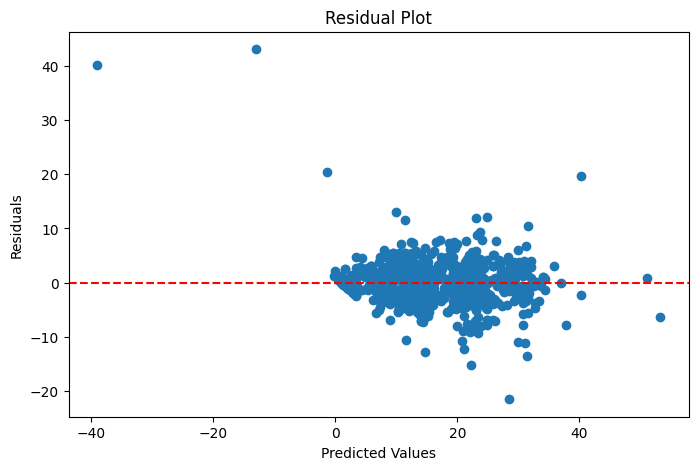

In [181]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

### Actual vs Predicted Plot

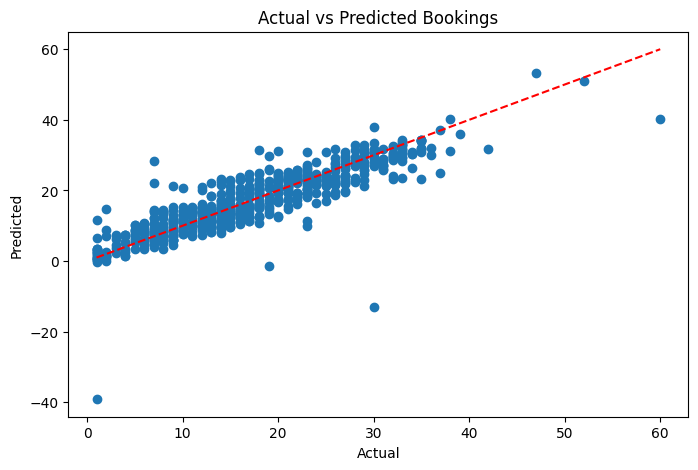

In [182]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.title("Actual vs Predicted Bookings")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()